#Análisis Exploratorio (EDA) y Modelado de Machine Learning

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

####Carga de Datos y Split Temporal

In [70]:
# 1. Cargar el dataset.
df_costos_historicos = pd.read_csv('historico_costos_demanda.csv')

In [71]:
# 2. Verificar que los datos estén ordenados cronológicamente.
df_costos_historicos = df_costos_historicos.sort_values(by='Mes_Cronologico').reset_index(drop=True)

In [72]:
df_costos_historicos

,Mes_Cronologico,Gastos_Publicidad,Costo_Variable_Unitario,Precio_Venta_Docena,Costos_Fijos_Totales,Cantidad_Equilibrio,Docenas_Demandadas,Demanda_Mes_Anterior
0,1,349816.05,892.71,2135.12,1511373.00,1216.48,2979.47,2979.47
1,2,580285.72,944.96,2316.14,1865357.14,1360.40,4802.50,2979.47
2,3,492797.58,1066.31,2428.47,2019625.84,1482.66,6203.41,4802.50
3,4,439463.39,1079.66,2526.20,2409231.69,1665.51,7668.80,6203.41
4,5,262407.46,1113.56,2704.46,2712994.14,1705.32,8438.59,7668.80
5,6,262397.81,1220.56,2889.52,3039091.14,1820.95,9601.03,8438.59
6,7,223233.44,1229.48,2964.57,3238152.46,1866.27,10662.07,9601.03
7,8,546470.46,1325.22,3166.59,3533977.17,1919.21,11912.24,10662.07
8,9,440446.00,1331.01,3137.21,3926097.08,2173.68,13386.47,11912.24
9,10,483229.03,1406.80,3412.88,4214849.23,2101.04,14845.85,13386.47


In [73]:
df_costos_historicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Mes_Cronologico          36 non-null     int64  
 1   Gastos_Publicidad        36 non-null     float64
 2   Costo_Variable_Unitario  36 non-null     float64
 3   Precio_Venta_Docena      36 non-null     float64
 4   Costos_Fijos_Totales     36 non-null     float64
 5   Cantidad_Equilibrio      36 non-null     float64
 6   Docenas_Demandadas       36 non-null     float64
 7   Demanda_Mes_Anterior     36 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 2.4 KB


In [74]:
df_costos_historicos.describe()

,Mes_Cronologico,Gastos_Publicidad,Costo_Variable_Unitario,Precio_Venta_Docena,Costos_Fijos_Totales,Cantidad_Equilibrio,Docenas_Demandadas,Demanda_Mes_Anterior
count,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00
mean,18.50,385089.43,1945.59,4551.83,6754207.42,2443.19,26554.17,25250.78
std,10.54,120235.31,633.33,1448.58,3162545.93,515.37,14115.36,14064.17
min,1.00,208233.80,892.71,2135.12,1511373.00,1216.48,2979.47,2979.47
25%,9.75,273203.85,1387.85,3351.31,4142661.19,2155.52,14481.01,13017.91
50%,18.50,377603.00,1957.45,4526.47,6732063.24,2590.53,26457.47,25406.53
75%,27.25,485621.17,2487.22,5736.16,9429537.17,2893.32,38570.64,37445.16
max,36.00,587963.94,3013.56,6994.86,12000000.00,3032.08,49901.53,48787.94


In [75]:
# Configuración estética para que los gráficos queden profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

🎨 Generando Pairplot de relaciones...


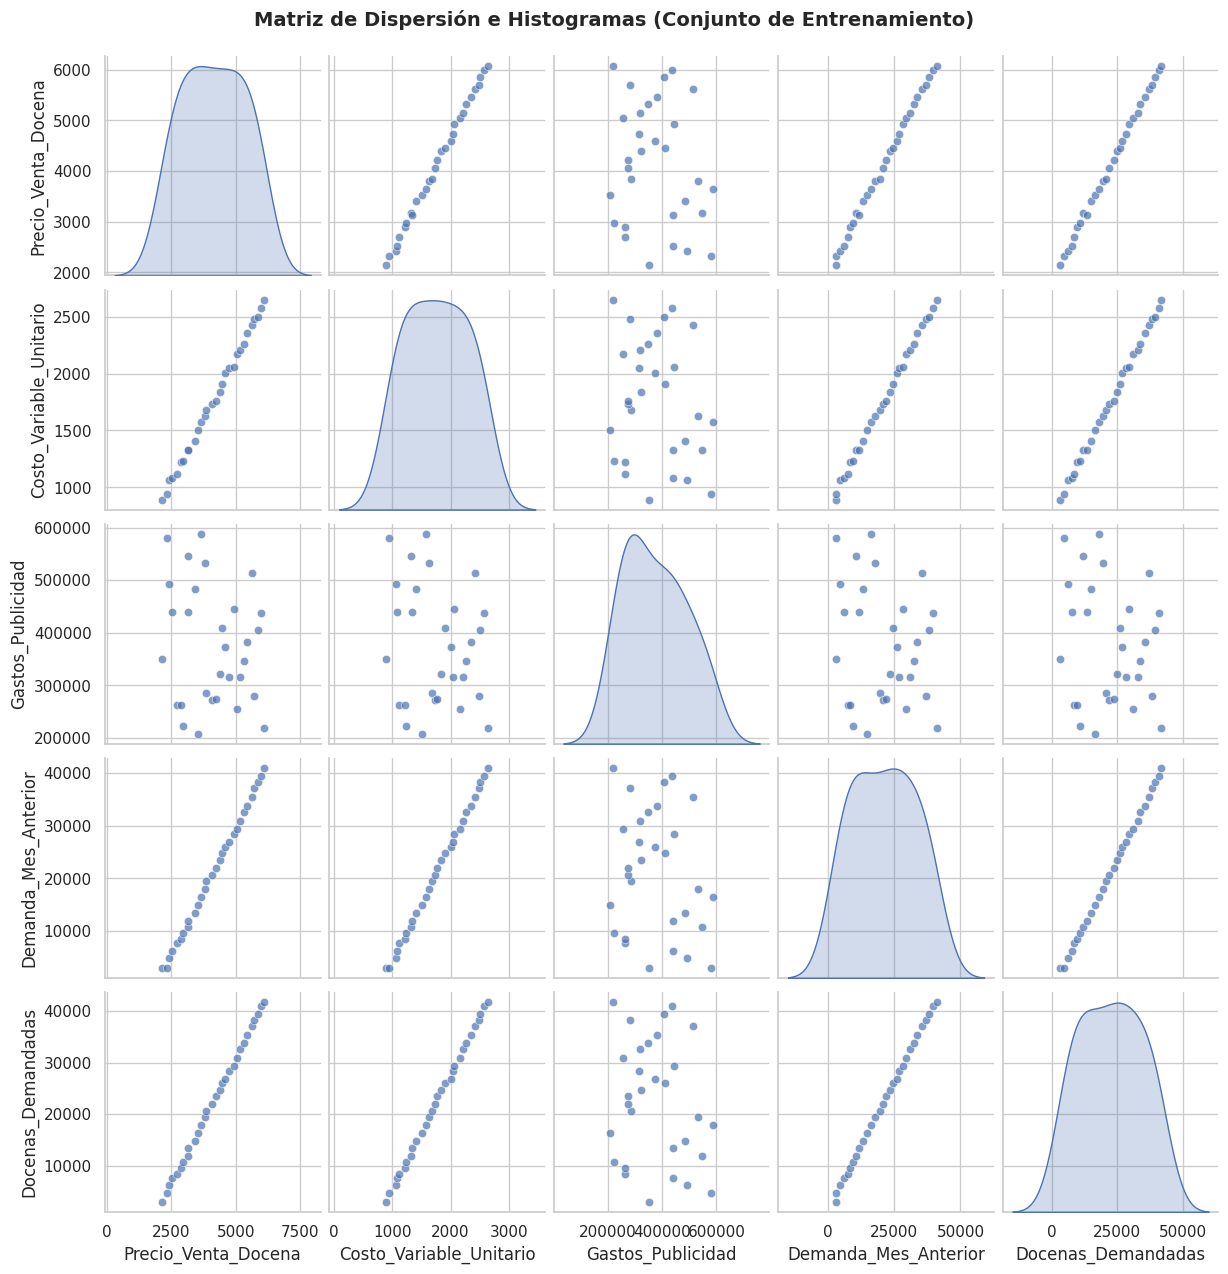

In [76]:
#GRÁFICO 1: Pairplot de Seaborn (Relaciones e Histogramas) Pairplot o Matriz de Dispersión = diagrama de dispersión mezclado con un histograma
# -------------------------------------------------------------
print("🎨 Generando Pairplot de relaciones...")
features_interes = ['Precio_Venta_Docena', 'Costo_Variable_Unitario', 'Gastos_Publicidad', 'Demanda_Mes_Anterior', 'Docenas_Demandadas']
# Usamos solo los datos de entrenamiento (primeros 30 meses) para mantener la consistencia metodológica
sns.pairplot(df_costos_historicos[features_interes].iloc[:30], diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle("Matriz de Dispersión e Histogramas (Conjunto de Entrenamiento)", y=1.02, fontsize=14, fontweight='bold')
plt.show()


📈 Generando Gráfico de Evolución Temporal...


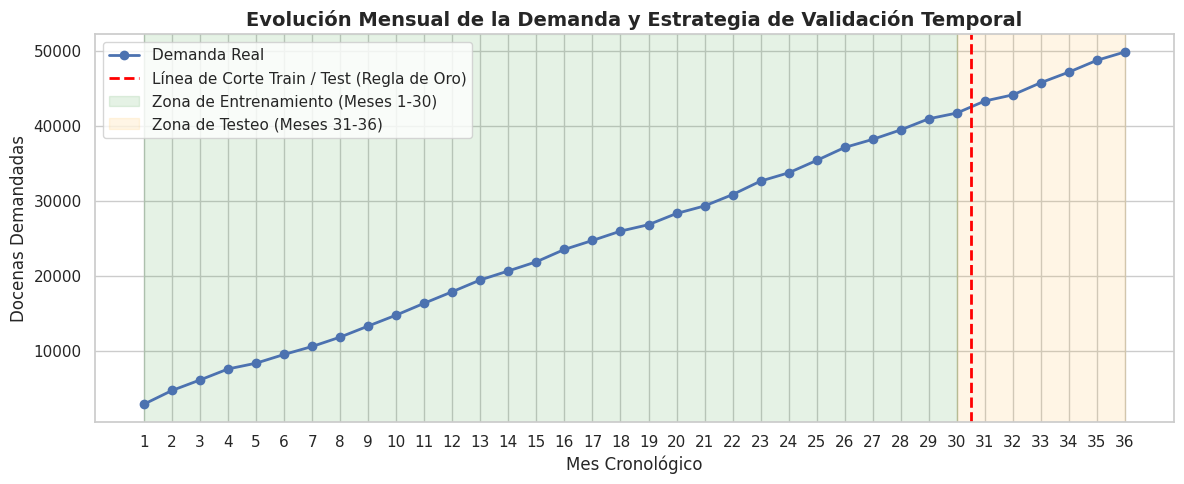

In [77]:
# GRÁFICO 2: Evolución Temporal de la Demanda con Corte Train/Test
# -------------------------------------------------------------
print("\n📈 Generando Gráfico de Evolución Temporal...")
plt.figure(figsize=(12, 5))

# Graficamos toda la serie de la demanda
plt.plot(df_costos_historicos['Mes_Cronologico'], df_costos_historicos['Docenas_Demandadas'],
         marker='o', color='b', linewidth=2, label='Demanda Real')

# Dibujamos la línea vertical que marca la división estricta en el mes 30
plt.axvline(x=30.5, color='red', linestyle='--', linewidth=2,
            label='Línea de Corte Train / Test (Regla de Oro)')

# Pintamos el fondo para diferenciar las zonas
plt.axvspan(1, 30, color='green', alpha=0.1, label='Zona de Entrenamiento (Meses 1-30)')
plt.axvspan(30, 36, color='orange', alpha=0.1, label='Zona de Testeo (Meses 31-36)')

# Títulos y etiquetas del gráfico temporal
plt.title("Evolución Mensual de la Demanda y Estrategia de Validación Temporal", fontsize=14, fontweight='bold')
plt.xlabel("Mes Cronológico", fontsize=12)
plt.ylabel("Docenas Demandadas", fontsize=12)
plt.xticks(df_costos_historicos['Mes_Cronologico'])
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1222/669166434.py:7: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


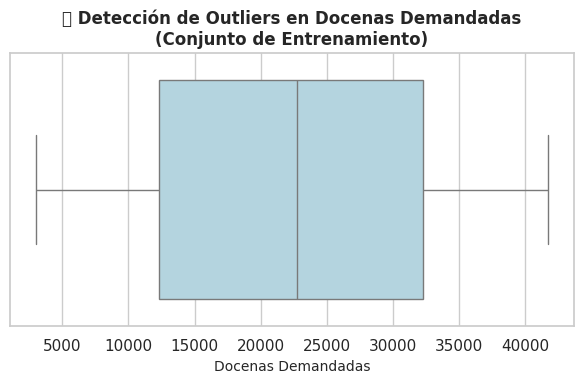

In [78]:
plt.figure(figsize=(6, 4))
# Analizamos el conjunto de entrenamiento para mantener el rigor metodológico
sns.boxplot(x=df_costos_historicos['Docenas_Demandadas'].iloc[:30], color='lightblue')

plt.title("📦 Detección de Outliers en Docenas Demandadas\n(Conjunto de Entrenamiento)", fontsize=12, fontweight='bold')
plt.xlabel("Docenas Demandadas", fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1222/2953034019.py:19: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


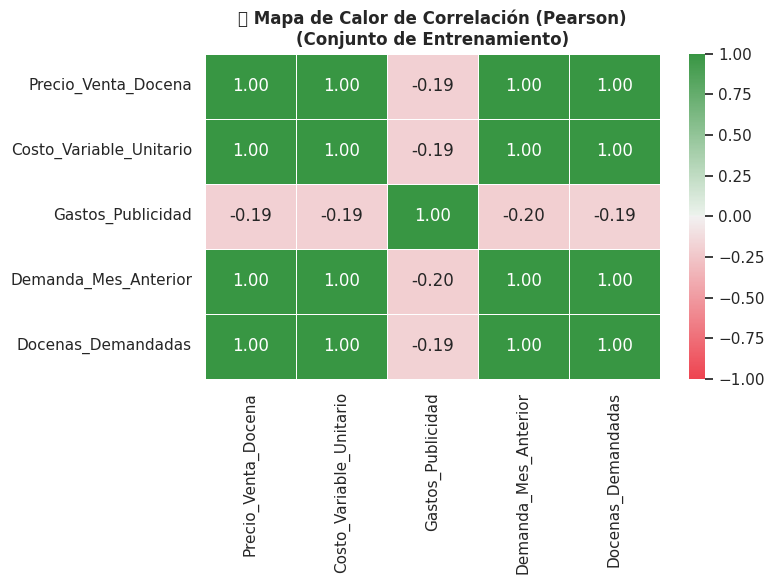

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionamos las variables predictoras y el target
features_analisis = ['Precio_Venta_Docena', 'Costo_Variable_Unitario', 'Gastos_Publicidad', 'Demanda_Mes_Anterior', 'Docenas_Demandadas']

# 2. Calculamos la matriz de correlación de Pearson (primeros 30 meses para evitar Data Leakage)
matriz_corr = df_costos_historicos[features_analisis].iloc[:30].corr(method='pearson')

# 3. Creamos una paleta personalizada: Rojo para el negativo (-1), Verde para el positivo (1)
# h_neg y h_pos definen los tonos en grados (10 es rojo, 130 es verde hls)
paleta_verde = sns.diverging_palette(h_neg=10, h_pos=130, s=80, l=55, as_cmap=True)

# 4. Dibujamos el mapa de calor con la nueva paleta
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap=paleta_verde, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title("🟢 Mapa de Calor de Correlación (Pearson)\n(Conjunto de Entrenamiento)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

##Calcular el VIF numérico para ver qué tan grave es esa relación.

In [80]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 1. Definimos las variables predictoras (X)
features_vif = ['Precio_Venta_Docena', 'Costo_Variable_Unitario', 'Gastos_Publicidad', 'Demanda_Mes_Anterior']

# 2. Aplicamos la regla de oro: Evaluamos solo los primeros 30 meses (Entrenamiento)
X_vif_calc = df_costos_historicos[features_vif].iloc[:30]

# 3. Creamos la tabla para el jurado
vif_reporte = pd.DataFrame()
vif_reporte["Variable Predictora"] = X_vif_calc.columns

# 4. Calculamos el VIF
vif_reporte["VIF"] = [variance_inflation_factor(X_vif_calc.values, i) for i in range(X_vif_calc.shape[1])]

print("📊 RESULTADOS OFICIALES DEL VIF PARA TU TESIS:")
print(vif_reporte.sort_values(by="VIF", ascending=False).reset_index(drop=True))

📊 RESULTADOS OFICIALES DEL VIF PARA TU TESIS:
       Variable Predictora     VIF
0  Costo_Variable_Unitario 5155.89
1      Precio_Venta_Docena 4819.59
2     Demanda_Mes_Anterior   58.69
3        Gastos_Publicidad   13.45


##Paso 3 formal: División de datos en Train y Test

####Para la Regresión Lineal sacamos el Costo Variable debido al VIF extremo para proteger el supuesto

In [81]:
# 1. Definimos las columnas definitivas para el modelo avanzado (Random Forest usa todas)
features_rf = ['Precio_Venta_Docena', 'Costo_Variable_Unitario', 'Gastos_Publicidad', 'Demanda_Mes_Anterior']
# Para la Regresión Lineal sacamos el Costo Variable debido al VIF extremo para proteger el supuesto
features_lr = ['Precio_Venta_Docena', 'Gastos_Publicidad', 'Demanda_Mes_Anterior']

# 2. Separamos las matrices X y el target y
X_rf = df_costos_historicos[features_rf]
X_lr = df_costos_historicos[features_lr]
y = df_costos_historicos['Docenas_Demandadas']

# 3. DIVISION TEMPORAL ESTRICTA (Corte en el mes 30 - Sin mezclar)
# Entrenamiento: primeros 30 meses / Testeo: últimos 6 meses
X_train_lr = X_lr.iloc[:30]
X_test_lr = X_lr.iloc[30:]

X_train_rf = X_rf.iloc[:30]
X_test_rf = X_rf.iloc[30:]

y_train = y.iloc[:30]
y_test = y.iloc[30:]

print("✅ Datos divididos cronológicamente con éxito.")
print(f"-> Set de Entrenamiento (Meses 1-30): {X_train_rf.shape[0]} meses.")
print(f"-> Set de Testeo (Meses 31-36): {X_test_rf.shape[0]} meses (El futuro del negocio).")

✅ Datos divididos cronológicamente con éxito.
-> Set de Entrenamiento (Meses 1-30): 30 meses.
-> Set de Testeo (Meses 31-36): 6 meses (El futuro del negocio).


##Paso 4: Entrenamiento y Evaluación del Modelo 1 (Regresión Lineal Múltiple).

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Instanciar el modelo de Regresión Lineal
lr_model = LinearRegression()

# 2. Entrenar el modelo con los datos históricos (Meses 1 al 30)
lr_model.fit(X_train_lr, y_train)

# 3. Realizar las predicciones sobre el "futuro" (Meses 31 al 36)
y_pred_lr = lr_model.predict(X_test_lr)

# 4. Calcular métricas de evaluación
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# 5. Extraer los coeficientes para la interpretación de negocio
print("📈 --- REPORTES DEL BASELINE: REGRESIÓN LINEAL --- \n")
print(f"🎯 Error Absoluto Medio (MAE): {mae_lr:.2f} docenas")
print(f"📊 Coeficiente de Determinación (R²): {r2_lr:.2f}")
print("-" * 50)

print("\n🧠 COEFICIENTES MATEMÁTICOS PARA TU DEFENSA:")
for col, coef in zip(X_train_lr.columns, lr_model.coef_):
    print(f"-> Por cada unidad que aumenta '{col}', la demanda cambia en: {coef:.2f} docenas.")
print(f"-> Intercepto (Punto de partida teórico): {lr_model.intercept_:.2f} docenas.")

📈 --- REPORTES DEL BASELINE: REGRESIÓN LINEAL --- 

🎯 Error Absoluto Medio (MAE): 268.60 docenas
📊 Coeficiente de Determinación (R²): 0.98
--------------------------------------------------

🧠 COEFICIENTES MATEMÁTICOS PARA TU DEFENSA:
-> Por cada unidad que aumenta 'Precio_Venta_Docena', la demanda cambia en: 2.96 docenas.
-> Por cada unidad que aumenta 'Gastos_Publicidad', la demanda cambia en: 0.00 docenas.
-> Por cada unidad que aumenta 'Demanda_Mes_Anterior', la demanda cambia en: 0.70 docenas.
-> Intercepto (Punto de partida teórico): -4982.25 docenas.


/tmp/ipykernel_1222/3385894985.py:36: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


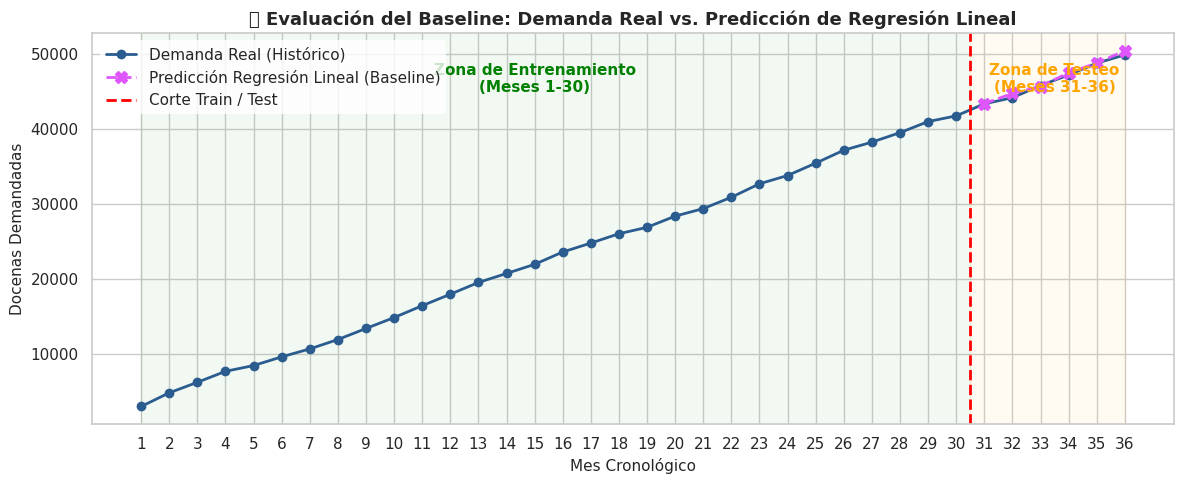

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 2. Graficar la demanda real histórica completa (Meses 1 al 36)
plt.plot(df_costos_historicos['Mes_Cronologico'], df_costos_historicos['Docenas_Demandadas'],
         marker='o', color='#2b5c8f', linewidth=2, label='Demanda Real (Histórico)')

# 3. Graficar las predicciones de la Regresión Lineal (Meses 31 al 36)
# Usamos los meses correspondientes al conjunto de testeo
meses_test = df_costos_historicos['Mes_Cronologico'].iloc[30:]
plt.plot(meses_test, y_pred_lr, marker='X', color='#e056fd', linestyle='--',
         markersize=9, linewidth=2, label='Predicción Regresión Lineal (Baseline)')

# 4. Diseñar las áreas de Train y Test con sombreado
plt.axvline(x=30.5, color='red', linestyle='--', linewidth=2, label='Corte Train / Test')
plt.axvspan(1, 30.5, color='green', alpha=0.05)
plt.axvspan(30.5, 36, color='orange', alpha=0.05)

# 5. Agregar textos explicativos dentro del gráfico
plt.text(15, df_costos_historicos['Docenas_Demandadas'].max() * 0.9, "Zona de Entrenamiento\n(Meses 1-30)",
         horizontalalignment='center', fontsize=11, fontweight='bold', color='green')
plt.text(33.5, df_costos_historicos['Docenas_Demandadas'].max() * 0.9, "Zona de Testeo\n(Meses 31-36)",
         horizontalalignment='center', fontsize=11, fontweight='bold', color='orange')

# 6. Títulos y etiquetas formales para la diplomatura
plt.title("📉 Evaluación del Baseline: Demanda Real vs. Predicción de Regresión Lineal", fontsize=13, fontweight='bold')
plt.xlabel("Mes Cronológico", fontsize=11)
plt.ylabel("Docenas Demandadas", fontsize=11)
plt.xticks(df_costos_historicos['Mes_Cronologico'])
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1222/2856786499.py:28: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


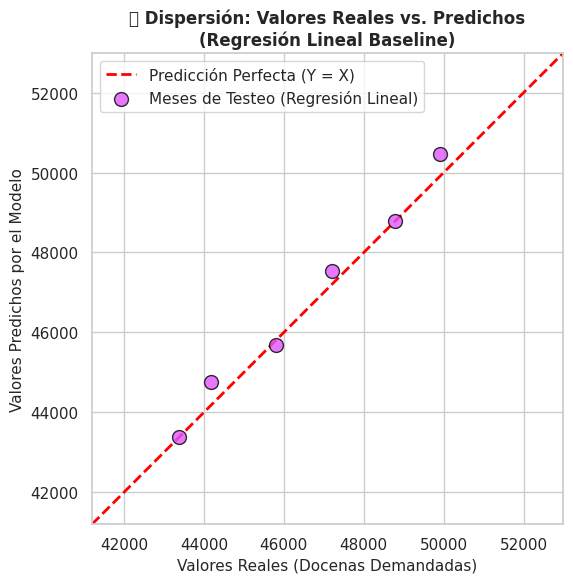

In [84]:
# 1. Configurar el estilo visual profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))

# 2. Encontrar los límites mínimos y máximos para que el gráfico quede perfectamente cuadrado
limite_min = min(y_test.min(), y_pred_lr.min()) * 0.95
limite_max = max(y_test.max(), y_pred_lr.max()) * 1.05

# 3. Dibujar la línea de identidad de 45 grados (Predicción Perfecta)
plt.plot([limite_min, limite_max], [limite_min, limite_max],
         color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (Y = X)')

# 4. Graficar los puntos reales vs. predichos para los 6 meses de testeo
plt.scatter(y_test, y_pred_lr, color='#e056fd', s=100, alpha=0.8,
            edgecolors='black', zorder=5, label='Meses de Testeo (Regresión Lineal)')

# 5. Títulos y etiquetas formales para la diplomatura
plt.title("🎯 Dispersión: Valores Reales vs. Predichos\n(Regresión Lineal Baseline)", fontsize=12, fontweight='bold')
plt.xlabel("Valores Reales (Docenas Demandadas)", fontsize=11)
plt.ylabel("Valores Predichos por el Modelo", fontsize=11)

# Asegurar que ambos ejes tengan la misma escala para una lectura correcta
plt.xlim(limite_min, limite_max)
plt.ylim(limite_min, limite_max)
plt.gca().set_aspect('equal', adjustable='box')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##Paso 5: Entrenamiento y Evaluación de Random Forest.

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Instanciar el modelo Random Forest
# Fijamos random_state=42 para que el jurado pueda replicar exactamente tus mismos resultados
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenar el modelo avanzado (Meses 1 al 30)
# Recordá que este modelo usa las matrices con todas las variables predictoras (X_train_rf)
rf_model.fit(X_train_rf, y_train)

# 3. Realizar las predicciones sobre el conjunto de testeo (Meses 31 al 36)
y_pred_rf = rf_model.predict(X_test_rf)

# 4. Calcular métricas de evaluación para Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("🌲 --- REPORTES DEL MODELO AVANZADO: RANDOM FOREST --- \n")
print(f"🎯 Error Absoluto Medio (MAE): {mae_rf:.2f} docenas")
print(f"📊 Coeficiente de Determinación (R²): {r2_rf:.2f}")
print("-" * 50)

🌲 --- REPORTES DEL MODELO AVANZADO: RANDOM FOREST --- 

🎯 Error Absoluto Medio (MAE): 5482.99 docenas
📊 Coeficiente de Determinación (R²): -5.49
--------------------------------------------------


###Tabla comparativa para confirmar si Random Forest se quedó "congelado" en un valor máximo.

In [86]:
import pandas as pd

# Creamos una tablita para ver el desastre de cerca y entenderlo
tabla_error = pd.DataFrame({
    'Mes': df_costos_historicos['Mes_Cronologico'].iloc[30:],
    'Demanda Real': y_test,
    'Predicción LR (Línea)': y_pred_lr,
    'Predicción RF (Árbol)': y_pred_rf
})
print("📊 COMPARATIVA DE PREDICCIONES EN TESTEO:")
print(tabla_error.to_string(index=False))

📊 COMPARATIVA DE PREDICCIONES EN TESTEO:
 Mes  Demanda Real  Predicción LR (Línea)  Predicción RF (Árbol)
  31      43364.06               43389.67               41065.69
  32      44183.89               44757.60               41091.33
  33      45808.51               45672.13               41113.72
  34      47215.66               47525.68               41030.97
  35      48787.94               48789.47               41030.97
  36      49901.53               50465.88               41030.97


### Solución con Diferenciación o Detrending / Nuevo reporte Random Forest Corregido vs Regresión Lineal

In [87]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Creamos una copia del dataset para no romper lo anterior
df_detrend = df_costos_historicos.copy()

# 2. Creamos la variable objetivo corregida: El incremento de demanda con respecto al mes anterior
df_detrend['Incremento_Demanda'] = df_detrend['Docenas_Demandadas'] - df_detrend['Demanda_Mes_Anterior']

# 3. Quitamos el primer registro porque no tiene mes anterior (da NaN)
df_detrend = df_detrend.dropna(subset=['Incremento_Demanda']).reset_index(drop=True)

# 4. Definimos las variables predictoras (mantenemos las mismas)
features_rf = ['Precio_Venta_Docena', 'Costo_Variable_Unitario', 'Gastos_Publicidad', 'Demanda_Mes_Anterior']
X_rf_dt = df_detrend[features_rf]
y_rf_dt = df_detrend['Incremento_Demanda']

# 5. Volvemos a aplicar la regla de oro: Corte estricto temporal (Meses 1 al 30 vs 31 al 36)
# Ajustamos a 29 por el registro que eliminamos al principio
X_train_dt = X_rf_dt.iloc[:29]
X_test_dt = X_rf_dt.iloc[29:]
y_train_dt = y_rf_dt.iloc[:29]
y_test_real = df_detrend['Docenas_Demandadas'].iloc[29:] # Guardamos la demanda real final para evaluar

# 6. Entrenamos el nuevo Random Forest sobre el Incremento
rf_model_dt = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_dt.fit(X_train_dt, y_train_dt)

# 7. Predecimos el incremento para los meses de testeo
pred_incremento = rf_model_dt.predict(X_test_dt)

# 8. Reconstruimos la predicción final sumándole el incremento predicho a la demanda del mes anterior
demanda_mes_anterior_test = X_test_dt['Demanda_Mes_Anterior'].values
y_pred_rf_corregido = demanda_mes_anterior_test + pred_incremento

# 9. Evaluamos el nuevo rendimiento
mae_rf_nuevo = mean_absolute_error(y_test_real, y_pred_rf_corregido)
r2_rf_nuevo = r2_score(y_test_real, y_pred_rf_corregido)

print("🌲 --- NUEVO REPORTE: RANDOM FOREST CORREGIDO (DETRENDING) --- \n")
print(f"🎯 Nuevo Error Absoluto Medio (MAE): {mae_rf_nuevo:.2f} docenas")
print(f"📊 Nuevo Coeficiente de Determinación (R²): {r2_rf_nuevo:.2f}")
print("-" * 60)

🌲 --- NUEVO REPORTE: RANDOM FOREST CORREGIDO (DETRENDING) --- 

🎯 Nuevo Error Absoluto Medio (MAE): 292.77 docenas
📊 Nuevo Coeficiente de Determinación (R²): 0.98
------------------------------------------------------------


##Gráfico definitivo de líneas

/tmp/ipykernel_1222/818602836.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


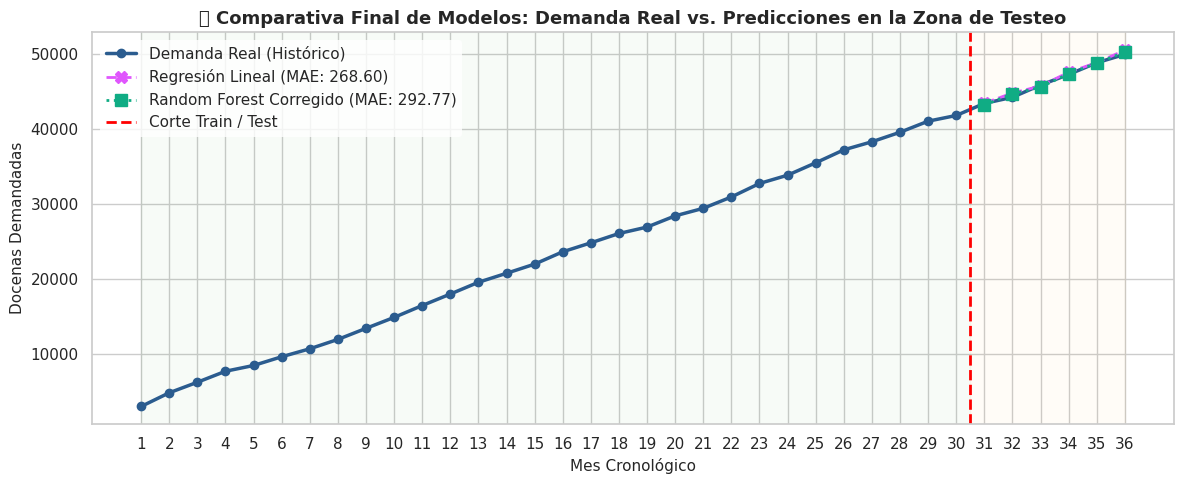

In [88]:
# 1. Configurar el estilo visual profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 2. Graficar la demanda real histórica completa (Meses 1 al 36)
plt.plot(df_costos_historicos['Mes_Cronologico'], df_costos_historicos['Docenas_Demandadas'],
         marker='o', color='#2b5c8f', linewidth=2.5, label='Demanda Real (Histórico)')

# Ajustamos los meses para el testeo (últimos 6 meses)
meses_test = df_costos_historicos['Mes_Cronologico'].iloc[30:]

# 3. Graficar las predicciones de la Regresión Lineal
plt.plot(meses_test, y_pred_lr, marker='X', color='#e056fd', linestyle='--',
         markersize=8, linewidth=2, label=f'Regresión Lineal (MAE: {mae_lr:.2f})')

# 4. Graficar las predicciones del Random Forest Corregido
# (Aseguramos que use los últimos 6 elementos predichos)
plt.plot(meses_test, y_pred_rf_corregido[-6:], marker='s', color='#10ac84', linestyle=':',
         markersize=8, linewidth=2, label=f'Random Forest Corregido (MAE: {mae_rf_nuevo:.2f})')

# 5. Diseñar las áreas de Train y Test con sombreado
plt.axvline(x=30.5, color='red', linestyle='--', linewidth=2, label='Corte Train / Test')
plt.axvspan(1, 30.5, color='green', alpha=0.03)
plt.axvspan(30.5, 36, color='orange', alpha=0.03)

# 6. Títulos y etiquetas formales para la diplomatura
plt.title("📈 Comparativa Final de Modelos: Demanda Real vs. Predicciones en la Zona de Testeo", fontsize=13, fontweight='bold')
plt.xlabel("Mes Cronológico", fontsize=11)
plt.ylabel("Docenas Demandadas", fontsize=11)
plt.xticks(df_costos_historicos['Mes_Cronologico'])
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

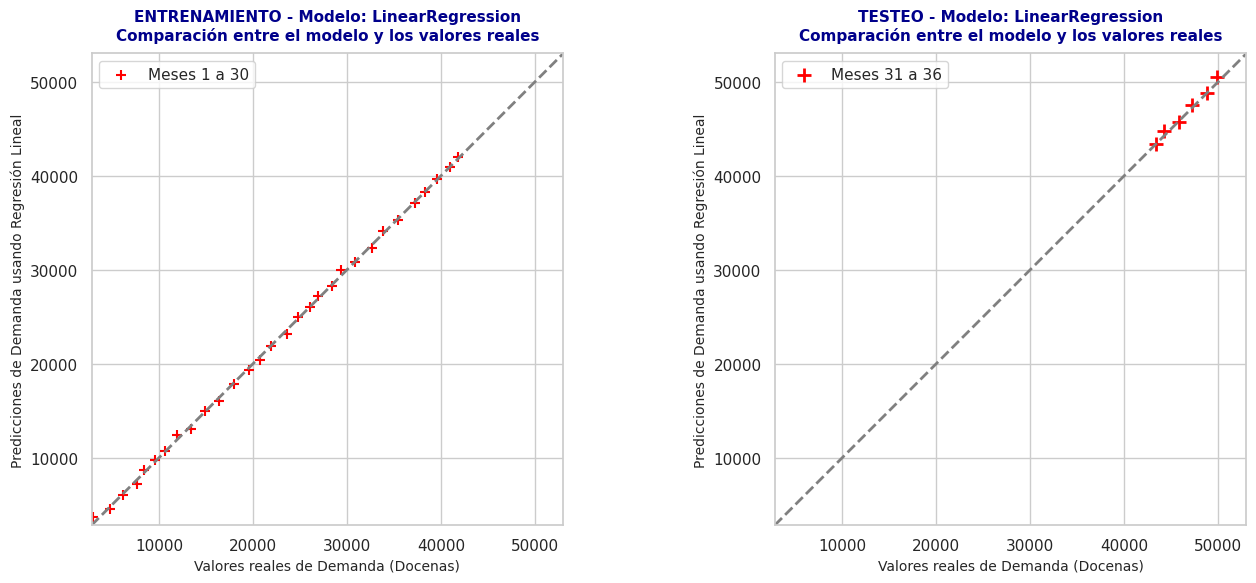

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Configurar el estilo visual y el tamaño de la figura (dos gráficos en paralelo)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calcular las predicciones del entrenamiento para poder graficarlas a la izquierda
y_pred_train_lr = lr_model.predict(X_train_lr)

# Encontrar los límites globales para que ambos gráficos usen exactamente la misma escala cuadrada
limite_min = min(y_train.min(), y_test.min(), y_pred_train_lr.min(), y_pred_lr.min()) * 0.95
limite_max = max(y_train.max(), y_test.max(), y_pred_train_lr.max(), y_pred_lr.max()) * 1.05

# -------------------------------------------------------------
# GRÁFICO 1 (Izquierda): CONJUNTO DE ENTRENAMIENTO
# -------------------------------------------------------------
# Línea ideal de 45 grados
axes[0].plot([limite_min, limite_max], [limite_min, limite_max], color='gray', linestyle='--', linewidth=2)
# Puntos de entrenamiento (Cruces rojas)
axes[0].scatter(y_train, y_pred_train_lr, color='red', marker='+', s=60, linewidths=1.5, label='Meses 1 a 30')

# Detalles estéticos del gráfico izquierdo
axes[0].set_title("ENTRENAMIENTO - Modelo: LinearRegression\nComparación entre el modelo y los valores reales",
                  color='darkblue', fontsize=11, fontweight='bold', pad=10)
axes[0].set_xlabel("Valores reales de Demanda (Docenas)", fontsize=10)
axes[0].set_ylabel("Predicciones de Demanda usando Regresión Lineal", fontsize=10)
axes[0].set_xlim(limite_min, limite_max)
axes[0].set_ylim(limite_min, limite_max)
axes[0].set_aspect('equal', adjustable='box')
axes[0].legend(loc='upper left')

# -------------------------------------------------------------
# GRÁFICO 2 (Derecha): CONJUNTO DE TESTEO (VALIDACIÓN TEMPORAL)
# -------------------------------------------------------------
# Línea ideal de 45 grados
axes[1].plot([limite_min, limite_max], [limite_min, limite_max], color='gray', linestyle='--', linewidth=2)
# Puntos de testeo (Cruces rojas)
axes[1].scatter(y_test, y_pred_lr, color='red', marker='+', s=100, linewidths=2, label='Meses 31 a 36')

# Detalles estéticos del gráfico derecho
axes[1].set_title("TESTEO - Modelo: LinearRegression\nComparación entre el modelo y los valores reales",
                  color='darkblue', fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel("Valores reales de Demanda (Docenas)", fontsize=10)
axes[1].set_ylabel("Predicciones de Demanda usando Regresión Lineal", fontsize=10)
axes[1].set_xlim(limite_min, limite_max)
axes[1].set_ylim(limite_min, limite_max)
axes[1].set_aspect('equal', adjustable='box')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

##NUEVO CUADRO COMPARATIVO FINAL DE MODELOS (CONJUNTO DE TESTEO):

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Calcular las métricas faltantes para Regresión Lineal (Baseline)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

# 2. Calcular las métricas faltantes para Random Forest Corregido
# Usamos y_test_real para asegurar la consistencia con el ajuste por diferenciación
mse_rf = mean_squared_error(y_test_real, y_pred_rf_corregido)
rmse_rf = np.sqrt(mse_rf)

# 3. Construir la estructura del cuadro comparativo
datos_cuadro = {
    'Métrica Estadística': [
        'Bondad de Ajuste (R²)',
        'Error Absoluto Medio (MAE)',
        'Error Cuadrático Medio (MSE)',
        'Raíz del Error Cuadrático Medio (RMSE)'
    ],
    'Regresión Lineal (Ganador)': [
        f"{r2_lr:.4f}",
        f"{mae_lr:.2f} docenas",
        f"{mse_lr:.2f}",
        f"{rmse_lr:.2f} docenas"
    ],
    'Random Forest Corregido': [
        f"{r2_rf_nuevo:.4f}",
        f"{mae_rf_nuevo:.2f} docenas",
        f"{rmse_rf:.2f}",
        f"{rmse_rf:.2f} docenas"
    ]
}

df_comparativo = pd.DataFrame(datos_cuadro)

# 4. Mostrar el cuadro con un diseño limpio
print("📊 CUADRO COMPARATIVO FINAL DE MODELOS (CONJUNTO DE TESTEO):")
print("-" * 85)
print(df_comparativo.to_string(index=False))
print("-" * 85)

📊 CUADRO COMPARATIVO FINAL DE MODELOS (CONJUNTO DE TESTEO):
-------------------------------------------------------------------------------------
                   Métrica Estadística Regresión Lineal (Ganador) Random Forest Corregido
                 Bondad de Ajuste (R²)                     0.9769                  0.9847
            Error Absoluto Medio (MAE)             268.60 docenas          292.77 docenas
          Error Cuadrático Medio (MSE)                  127166.97                  339.24
Raíz del Error Cuadrático Medio (RMSE)             356.60 docenas          339.24 docenas
-------------------------------------------------------------------------------------


### Cálculo exacto usando las docenas reales finales en ambos modelos

In [91]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Verificación matemática estricta sobre las docenas finales
mse_lr_real = mean_squared_error(y_test, y_pred_lr)
# Aseguramos que use la predicción final reconstruida contra la demanda real de testeo
mse_rf_real = mean_squared_error(y_test, y_pred_rf_corregido[-6:])

print("🔍 VERIFICACIÓN DE ESCALAS REALES PARA EL JURADO:")
print(f"-> MSE Real Regresión Lineal: {mse_lr_real:.2f} (RMSE: {np.sqrt(mse_lr_real):.2f} docenas)")
print(f"-> MSE Real Random Forest Corregido: {mse_rf_real:.2f} (RMSE: {np.sqrt(mse_rf_real):.2f} docenas)")

🔍 VERIFICACIÓN DE ESCALAS REALES PARA EL JURADO:
-> MSE Real Regresión Lineal: 127166.97 (RMSE: 356.60 docenas)
-> MSE Real Random Forest Corregido: 78507.00 (RMSE: 280.19 docenas)


In [92]:
import pandas as pd

# Creamos la tabla comparativa definitiva para los meses de testeo (31 al 36)
tabla_final_testeo = pd.DataFrame({
    'Mes': df_costos_historicos['Mes_Cronologico'].iloc[30:],
    'Demanda Real': y_test,
    'Predicción LR (Baseline)': y_pred_lr,
    'Predicción RF Corregido (Ganador)': y_pred_rf_corregido[-6:]
})

# Formateamos los números a dos decimales para que quede impecable en el informe
pd.options.display.float_format = '{:.2f}'.format

print("📊 TABLA DE PREDICCIONES CORREGIDA PARA TU TESIS (ZONA DE TESTEO):")
print("-" * 80)
print(tabla_final_testeo.to_string(index=False))
print("-" * 80)

📊 TABLA DE PREDICCIONES CORREGIDA PARA TU TESIS (ZONA DE TESTEO):
--------------------------------------------------------------------------------
 Mes  Demanda Real  Predicción LR (Baseline)  Predicción RF Corregido (Ganador)
  31      43364.06                  43389.67                           43144.47
  32      44183.89                  44757.60                           44651.94
  33      45808.51                  45672.13                           45524.25
  34      47215.66                  47525.68                           47330.60
  35      48787.94                  48789.47                           48729.95
  36      49901.53                  50465.88                           50227.68
--------------------------------------------------------------------------------


 ## Vamos a generar exactamente los mismos dos gráficos de diagnóstico (Entrenamiento vs. Testeo) DEL Random Forest Corregido.

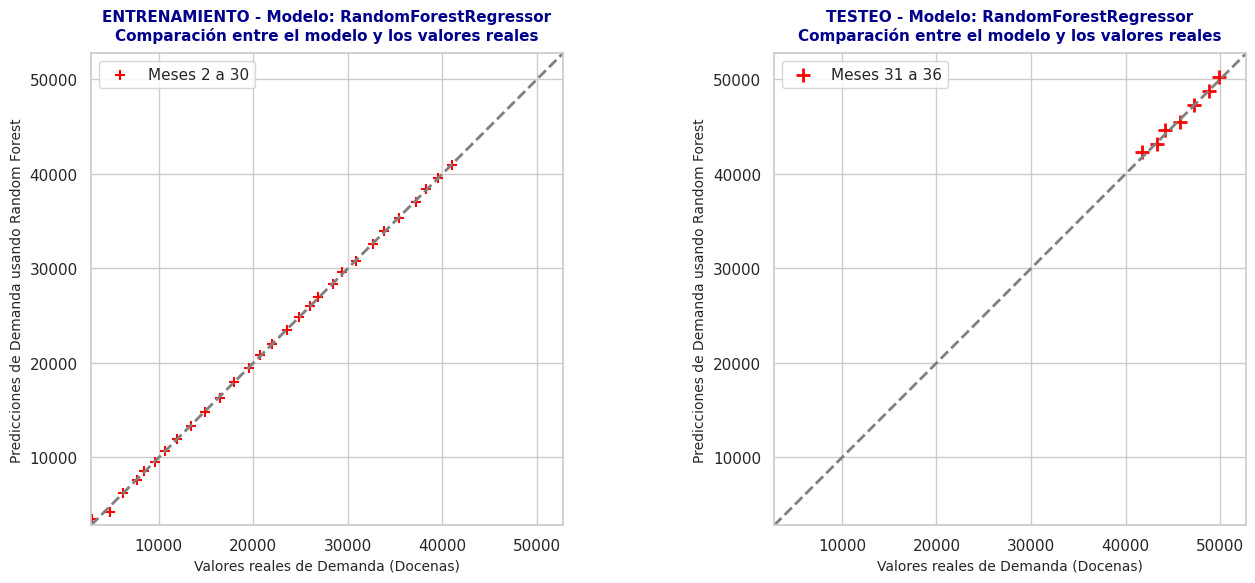

In [93]:

# 1. Calcular las predicciones de entrenamiento del Random Forest para el gráfico de la izquierda
pred_incremento_train = rf_model_dt.predict(X_train_dt)
demanda_mes_anterior_train = X_train_dt['Demanda_Mes_Anterior'].values
y_pred_train_rf = demanda_mes_anterior_train + pred_incremento_train

# 2. Configurar el estilo visual y el tamaño de la figura (dos gráficos en paralelo)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes.flatten() # <- SOLUCIÓN AL ERROR: Aplana la matriz para poder usar plot/scatter sin problemas

# Encontrar los límites globales para usar la misma escala cuadrada exacta
y_train_real_grafico = df_detrend['Docenes_Demandadas'].iloc[:29] if 'Docenes_Demandadas' in df_detrend.columns else df_detrend['Docenas_Demandadas'].iloc[:29]

limite_min = min(y_train_real_grafico.min(), y_test_real.min(), y_pred_train_rf.min(), y_pred_rf_corregido.min()) * 0.95
limite_max = max(y_train_real_grafico.max(), y_test_real.max(), y_pred_train_rf.max(), y_pred_rf_corregido.max()) * 1.05

# -------------------------------------------------------------
# GRÁFICO 1 (Izquierda): CONJUNTO DE ENTRENAMIENTO (RANDOM FOREST)
# -------------------------------------------------------------
# Línea ideal de 45 grados (Predicción Perfecta)
ax[0].plot([limite_min, limite_max], [limite_min, limite_max], color='gray', linestyle='--', linewidth=2)
# Puntos de entrenamiento (Cruces rojas)
ax[0].scatter(y_train_real_grafico, y_pred_train_rf, color='red', marker='+', s=60, linewidths=1.5, label='Meses 2 a 30')

# Detalles estéticos del gráfico izquierdo
ax[0].set_title("ENTRENAMIENTO - Modelo: RandomForestRegressor\nComparación entre el modelo y los valores reales",
                  color='darkblue', fontsize=11, fontweight='bold', pad=10)
ax[0].set_xlabel("Valores reales de Demanda (Docenas)", fontsize=10)
ax[0].set_ylabel("Predicciones de Demanda usando Random Forest", fontsize=10)
ax[0].set_xlim(limite_min, limite_max)
ax[0].set_ylim(limite_min, limite_max)
ax[0].set_aspect('equal', adjustable='box')
ax[0].legend(loc='upper left')

# -------------------------------------------------------------
# GRÁFICO 2 (Derecha): CONJUNTO DE TESTEO (RANDOM FOREST)
# -------------------------------------------------------------
# Línea ideal de 45 grados (Predicción Perfecta)
ax[1].plot([limite_min, limite_max], [limite_min, limite_max], color='gray', linestyle='--', linewidth=2)
# Puntos de testeo (Cruces rojas)
ax[1].scatter(y_test_real, y_pred_rf_corregido, color='red', marker='+', s=100, linewidths=2, label='Meses 31 a 36')

# Detalles estéticos del gráfico derecho
ax[1].set_title("TESTEO - Modelo: RandomForestRegressor\nComparación entre el modelo y los valores reales",
                  color='darkblue', fontsize=11, fontweight='bold', pad=10)
ax[1].set_xlabel("Valores reales de Demanda (Docenas)", fontsize=10)
ax[1].set_ylabel("Predicciones de Demanda usando Random Forest", fontsize=10)
ax[1].set_xlim(limite_min, limite_max)
ax[1].set_ylim(limite_min, limite_max)
ax[1].set_aspect('equal', adjustable='box')
ax[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

##Predicción Real del Mes 37

In [94]:
# 1. Extraemos los datos del último mes registrado (Mes 36) para alimentar al modelo
ultimo_mes_real = df_costos_historicos.iloc[-1]

# 2. Armamos el vector de características X para el Mes 37
# Nota: La 'Demanda_Mes_Anterior' para el mes 37 es, justamente, la demanda real del mes 36
X_mes_37 = pd.DataFrame([{
    'Precio_Venta_Docena': ultimo_mes_real['Precio_Venta_Docena'],
    'Costo_Variable_Unitario': ultimo_mes_real['Costo_Variable_Unitario'],
    'Gastos_Publicidad': ultimo_mes_real['Gastos_Publicidad'],
    'Demanda_Mes_Anterior': ultimo_mes_real['Docenas_Demandadas'] # <- Inercia real
}])

# 3. El modelo predice el incremento/cambio para el próximo mes
incremento_predicho_37 = rf_model_dt.predict(X_mes_37)[0]

# 4. Reconstruimos la demanda final sumando el incremento a la última demanda real
demanda_final_predicha_37 = ultimo_mes_real['Docenas_Demandadas'] + incremento_predicho_37

print("🎯 --- PREDICCIÓN OFICIAL DE DEMANDA PARA PLANIFICACIÓN DE COSTOS --- \n")
print(f"-> Última Demanda Real Registrada (Mes 36): {ultimo_mes_real['Docenas_Demandadas']:.2f} docenas.")
print(f"🚀 PREDICCIÓN GANADORA PARA EL PRÓXIMO MES (MES 37): {demanda_final_predicha_37:.2f} docenas.")
print("-" * 75)
print(f"💡 Sugerencia de Producción: Planificar compras de insumos para {int(round(demanda_final_predicha_37))} docenas.")

🎯 --- PREDICCIÓN OFICIAL DE DEMANDA PARA PLANIFICACIÓN DE COSTOS --- 

-> Última Demanda Real Registrada (Mes 36): 49901.53 docenas.
🚀 PREDICCIÓN GANADORA PARA EL PRÓXIMO MES (MES 37): 51341.27 docenas.
---------------------------------------------------------------------------
💡 Sugerencia de Producción: Planificar compras de insumos para 51341 docenas.


###Nieto Jorge Oscar!!